/tmp/ipykernel_3832292/1127347727.py:134: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


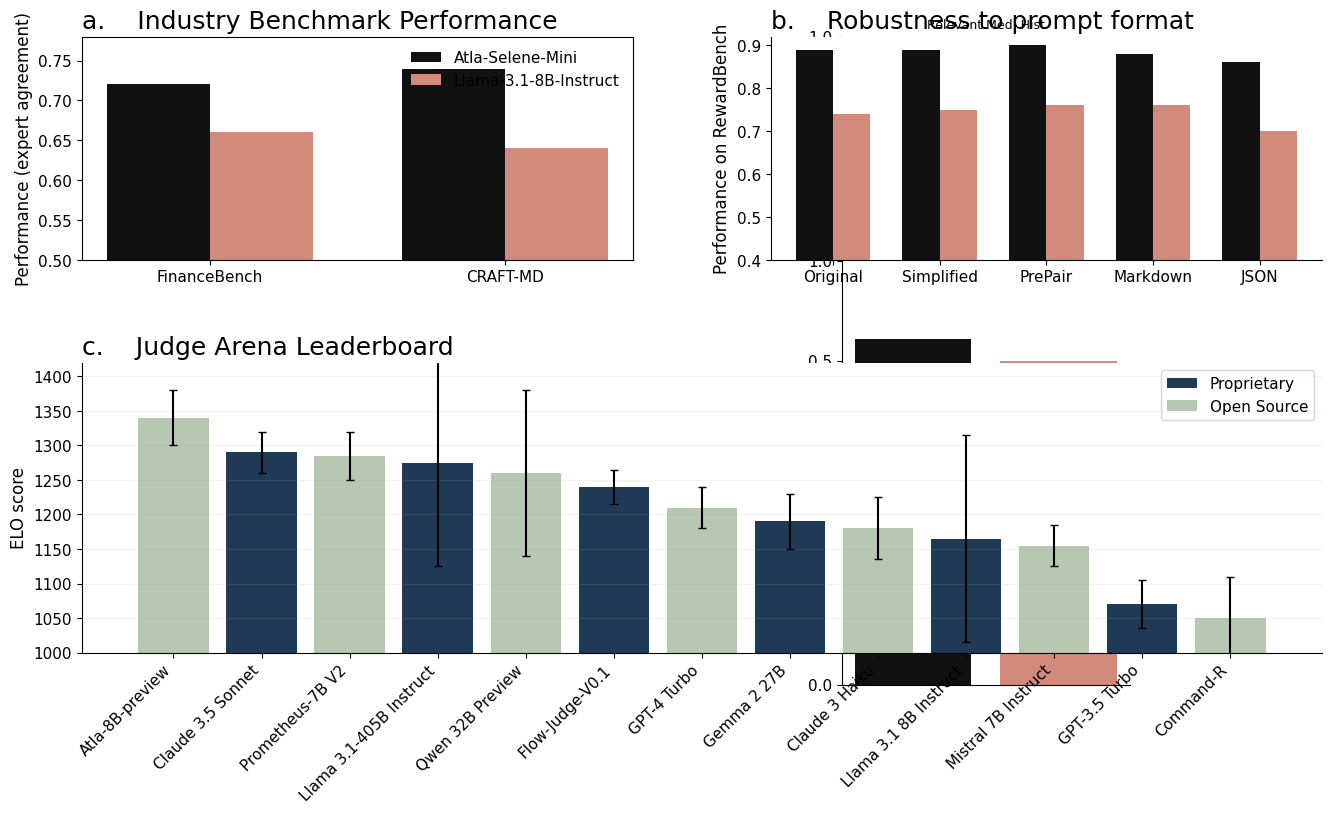

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Global Style
# -----------------------------
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.titlesize": 18,
    "axes.labelsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
})

# Colors
salmon = "#D28B7B"
black = "#111111"
dark_blue = "#1F3A56"
light_green = "#B8C7B1"

# -----------------------------
# Figure Layout
# -----------------------------
fig = plt.figure(figsize=(16, 8))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.3], hspace=0.4, wspace=0.25)

# =====================================================
# (a) Industry Benchmark Performance
# =====================================================
ax1 = fig.add_subplot(gs[0, 0])

benchmarks = ["FinanceBench", "CRAFT-MD"]
x = np.arange(len(benchmarks))
width = 0.35

llama = [0.66, 0.64]
atla = [0.72, 0.74]

ax1.bar(x - width/2, atla, width, color=black, label="Atla-Selene-Mini")
ax1.bar(x + width/2, llama, width, color=salmon, label="Llama-3.1-8B-Instruct")

ax1.set_ylabel("Performance (expert agreement)")
ax1.set_xticks(x)
ax1.set_xticklabels(benchmarks)
ax1.set_ylim(0.5, 0.78)
ax1.set_title("a.    Industry Benchmark Performance", loc="left")
ax1.legend(frameon=False)

# Small inset charts (right side of panel a)
inset_positions = [
    [0.60, 0.63, 0.18, 0.25],
    [0.60, 0.35, 0.18, 0.25],
    [0.60, 0.07, 0.18, 0.25],
]
titles = ["Relevant Med. Hist", "Most Likely Diag.", "Medical Term."]
values_black = [0.72, 0.61, 0.92]
values_salmon = [0.65, 0.50, 0.78]

for pos, title, vb, vs in zip(inset_positions, titles, values_black, values_salmon):
    ax_in = fig.add_axes(pos)
    ax_in.bar([0], [vb], width=0.4, color=black)
    ax_in.bar([0.5], [vs], width=0.4, color=salmon)
    ax_in.set_ylim(0, 1)
    ax_in.set_xticks([])
    ax_in.set_yticks([0, 0.5, 1])
    ax_in.set_title(title, fontsize=9)
    ax_in.spines[['top', 'right']].set_visible(False)

# =====================================================
# (b) Robustness to Prompt Format
# =====================================================
ax2 = fig.add_subplot(gs[0, 1])

formats = ["Original", "Simplified", "PrePair", "Markdown", "JSON"]
x2 = np.arange(len(formats))

robust_black = [0.89, 0.89, 0.90, 0.88, 0.86]
robust_salmon = [0.74, 0.75, 0.76, 0.76, 0.70]

ax2.bar(x2 - width/2, robust_black, width, color=black)
ax2.bar(x2 + width/2, robust_salmon, width, color=salmon)

ax2.set_xticks(x2)
ax2.set_xticklabels(formats)
ax2.set_ylim(0.4, 0.92)
ax2.set_ylabel("Performance on RewardBench")
ax2.set_title("b.    Robustness to prompt format", loc="left")
ax2.spines[['top', 'right']].set_visible(False)

# =====================================================
# (c) Judge Arena Leaderboard
# =====================================================
ax3 = fig.add_subplot(gs[1, :])

models = [
    "Atla-8B-preview", "Claude 3.5 Sonnet", "Prometheus-7B V2",
    "Llama 3.1-405B Instruct", "Qwen 32B Preview", "Flow-Judge-V0.1",
    "GPT-4 Turbo", "Gemma 2 27B", "Claude 3 Haiku",
    "Llama 3.1 8B Instruct", "Mistral 7B Instruct",
    "GPT-3.5 Turbo", "Command-R"
]

elo = np.array([1340, 1290, 1285, 1275, 1260, 1240,
                1210, 1190, 1180, 1165, 1155,
                1070, 1050])

error = np.array([40, 30, 35, 150, 120, 25,
                  30, 40, 45, 150, 30,
                  35, 60])

colors = [light_green if i % 2 == 0 else dark_blue for i in range(len(models))]

ax3.bar(range(len(models)), elo, yerr=error,
        color=colors, capsize=3, edgecolor="none")

ax3.set_xticks(range(len(models)))
ax3.set_xticklabels(models, rotation=45, ha="right")
ax3.set_ylabel("ELO score")
ax3.set_ylim(1000, 1420)
ax3.set_title("c.    Judge Arena Leaderboard", loc="left")

ax3.spines[['top', 'right']].set_visible(False)
ax3.grid(axis='y', linestyle='-', alpha=0.15)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=dark_blue, label="Proprietary"),
    Patch(facecolor=light_green, label="Open Source")
]
ax3.legend(handles=legend_elements, frameon=True)

plt.tight_layout()
plt.show()

# Post-process Results

In [18]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import re
from typing import Optional, Tuple

# ────────────────────────────────────────────────
#  CONFIG
# ────────────────────────────────────────────────

RESULTS_DIR = Path("/home/nckh2/qa/SLM/results/gemma")

ANALYSIS_BASE = RESULTS_DIR / "multi_symbol_analysis_insights"
ANALYSIS_BASE.mkdir(parents=True, exist_ok=True)

ULTIMATE_DIR = ANALYSIS_BASE / "ultimate_aggregated_results"
ULTIMATE_DIR.mkdir(parents=True, exist_ok=True)

BACKTEST_DIR = ANALYSIS_BASE / "backtest"
BACKTEST_DIR.mkdir(parents=True, exist_ok=True)

INITIAL_CAPITAL   = 10000.0
TRANSACTION_COST  = 0.001      # 0.1% per entry
EVAL_STEPS        = [1, 7, 14, 21, 28]

FILENAME_PATTERN = re.compile(r'^([A-Z]{1,6})_lb(\d+)_fh(\d+)_(predictions|metrics)\.json$')

# ────────────────────────────────────────────────
#  HELPERS
# ────────────────────────────────────────────────

def discover_symbols() -> list[str]:
    symbols = set()
    for p in RESULTS_DIR.glob("*_predictions.json"):
        m = FILENAME_PATTERN.match(p.name)
        if m and m.group(3) == '28':
            symbols.add(m.group(1))
    return sorted(symbols)


def find_prediction_file(symbol: str, lookback: int) -> Optional[Path]:
    candidates = list(RESULTS_DIR.glob(f"{symbol}_lb{lookback}_fh28_predictions.json"))
    return candidates[0] if candidates else None


def load_hist_for_symbol(symbol: str) -> Optional[pd.DataFrame]:
    hist_path = Path(f"/home/nckh2/qa/SLM/data/{symbol}_1d_full.csv")
    if not hist_path.exists():
        print(f"  Historical data missing: {hist_path}")
        return None
    df = pd.read_csv(hist_path)
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values('Date').reset_index(drop=True)
    return df[['Date', 'close']].rename(columns={'close': 'hist_close'})


def load_and_prepare_predictions(symbol: str, lookback: int, hist_df: pd.DataFrame) -> Optional[pd.DataFrame]:
    pred_path = find_prediction_file(symbol, lookback)
    if not pred_path:
        return None

    with open(pred_path, 'r', encoding='utf-8') as f:
        data = json.load(f)

    df = pd.DataFrame(data)
    df['date'] = pd.to_datetime(df['date'])
    df = df.sort_values('date').reset_index(drop=True)

    for step in EVAL_STEPS:
        df[f'pred_{step}d']   = df['predicted'].apply(lambda x: x[step-1] if isinstance(x, list) and len(x) >= step else np.nan)
        df[f'actual_{step}d'] = df['actual'].apply(  lambda x: x[step-1] if isinstance(x, list) and len(x) >= step else np.nan)

    df = df.merge(hist_df, left_on='date', right_on='Date', how='left')
    df.rename(columns={'hist_close': 'entry_price'}, inplace=True)
    df.drop(columns=['Date'], errors='ignore', inplace=True)
    df['lookback'] = lookback
    return df


def backtest_one_step(df_pred: pd.DataFrame, step_days: int, capital: float = INITIAL_CAPITAL) -> Tuple[Optional[dict], Optional[pd.DataFrame]]:
    if df_pred.empty:
        return None, None

    pred_col = f'pred_{step_days}d'
    act_col  = f'actual_{step_days}d'
    if pred_col not in df_pred.columns or act_col not in df_pred.columns:
        return None, None

    df = df_pred.copy()
    df['expected_ret'] = df[pred_col] / df['entry_price'] - 1
    df['signal'] = (df['expected_ret'] > 0).astype(int)

    # Non-overlapping periods
    df_bt = df.iloc[::step_days].copy().reset_index(drop=True)
    df_bt['realized_ret'] = df_bt[act_col] / df_bt['entry_price'] - 1
    df_bt['trade_return'] = df_bt['signal'] * df_bt['realized_ret'] - TRANSACTION_COST * df_bt['signal']

    df_bt['cum_strategy'] = (1 + df_bt['trade_return'].fillna(0)).cumprod()
    df_bt['cum_bh']       = (1 + df_bt['realized_ret'].fillna(0)).cumprod()

    final_strategy = capital * df_bt['cum_strategy'].iloc[-1]
    final_bh       = capital * df_bt['cum_bh'].iloc[-1]

    returns = df_bt['trade_return'].dropna()
    if len(returns) < 2:
        sharpe = cagr = max_dd = np.nan
    else:
        ann_factor = 252 / step_days
        sharpe = returns.mean() / returns.std() * np.sqrt(ann_factor) if returns.std() > 0 else np.nan
        cum = df_bt['cum_strategy']
        dd = cum / cum.cummax() - 1
        max_dd = dd.min()
        years = len(df_bt) * step_days / 252.0
        cagr = (df_bt['cum_strategy'].iloc[-1] ** (1 / years) - 1) if years > 0 else np.nan

    win_rate = (df_bt['trade_return'] > 0).mean() if len(df_bt) > 0 else np.nan

    metrics = {
        'step_days': step_days,
        'final_capital': final_strategy,
        'profit_pct': (final_strategy / capital - 1) * 100,
        'bh_profit_pct': (final_bh / capital - 1) * 100,
        'sharpe': sharpe,
        'max_dd_pct': max_dd * 100 if max_dd is not None else np.nan,
        'cagr_pct': cagr * 100 if cagr is not None else np.nan,
        'win_rate_pct': win_rate * 100 if win_rate is not None else np.nan,
        'n_trades': df_bt['signal'].sum(),
        'n_periods': len(df_bt)
    }
    return metrics, df_bt


def load_metrics_for_symbol(symbol: str) -> Optional[pd.DataFrame]:
    dfs = []
    for p in RESULTS_DIR.glob(f"{symbol}_lb*_fh28_metrics.json"):
        try:
            with open(p, 'r', encoding='utf-8') as f:
                data = json.load(f)
            if 'metrics_per_step' not in data:
                continue
            lb = data['lookback']
            df = pd.DataFrame(data['metrics_per_step'])
            df['symbol']   = symbol
            df['lookback'] = lb
            dfs.append(df)
        except Exception as e:
            print(f"  Skip metrics file {p.name}: {e}")
    return pd.concat(dfs, ignore_index=True) if dfs else None


# ────────────────────────────────────────────────
#  HEATMAP UTILITY (robust version)
# ────────────────────────────────────────────────

def save_heatmap(
    df: pd.DataFrame,
    value_col: str,
    title: str,
    save_path: Path,
    cmap: str = 'YlOrRd_r',
    index_col: str = 'lookback',
    step_col: Optional[str] = None
):
    if df is None or df.empty or value_col not in df.columns:
        print(f"  Skip heatmap {save_path.name} — missing data or column '{value_col}'")
        return

    # Determine which column to use for steps/horizon
    if step_col is None:
        if 'horizon_step' in df.columns:
            step_col = 'horizon_step'
        elif 'step_days' in df.columns:
            step_col = 'step_days'
        else:
            print(f"  Cannot create {save_path.name} — no step/horizon column found")
            return

    if step_col not in df.columns:
        print(f"  Skip {save_path.name} — column '{step_col}' not found")
        return

    try:
        pivot = df.pivot_table(
            index=index_col,
            columns=step_col,
            values=value_col,
            aggfunc='mean'
        ).round(2)

        if pivot.shape[0] < 1 or pivot.shape[1] < 1:
            print(f"  Pivot too small for {save_path.name}")
            return

        plt.figure(figsize=(8, 6))
        sns.heatmap(pivot, annot=True, fmt=".2f", cmap=cmap, linewidths=0.5,
                    cbar_kws={'label': value_col})
        plt.title(title)
        plt.xlabel("Forecast Step (days)")
        plt.ylabel("Lookback (days)")
        plt.tight_layout()
        plt.savefig(save_path, dpi=140, bbox_inches='tight')
        plt.close()
        print(f"  Saved: {save_path.name}")
    except Exception as e:
        print(f"  Heatmap error {save_path.name}: {e}")


# ────────────────────────────────────────────────
#  PER-SYMBOL PROCESSING
# ────────────────────────────────────────────────

def process_symbol(symbol: str) -> Tuple[Optional[pd.DataFrame], Optional[pd.DataFrame]]:
    print(f"\n{'═' * 24} {symbol} {'═' * 24}")

    hist_df = load_hist_for_symbol(symbol)
    if hist_df is None:
        return None, None

    symbol_dir = BACKTEST_DIR / symbol
    symbol_dir.mkdir(exist_ok=True)

    # ── Metrics ──
    df_metrics = load_metrics_for_symbol(symbol)
    if df_metrics is not None and not df_metrics.empty:
        save_heatmap(
            df_metrics, 'mape',
            f"{symbol} – Avg MAPE by Lookback & Step",
            symbol_dir / f"{symbol}_heatmap_mape.png",
            cmap='YlOrRd_r'
        )

    # ── Backtest ──
    bt_results = []
    best_profit_df_bt = best_sharpe_df_bt = None
    best_profit = -np.inf
    best_sharpe = -np.inf

    for lb in [1, 7, 14, 21, 28]:
        df_pred = load_and_prepare_predictions(symbol, lb, hist_df)
        if df_pred is None:
            continue

        for step in EVAL_STEPS:
            res, df_bt = backtest_one_step(df_pred, step)
            if res:
                res['symbol'] = symbol
                res['lookback'] = lb
                bt_results.append(res)

                if res['profit_pct'] > best_profit:
                    best_profit = res['profit_pct']
                    best_profit_df_bt = df_bt.assign(lookback=lb, step_days=step)

                if res['sharpe'] > best_sharpe:
                    best_sharpe = res['sharpe']
                    best_sharpe_df_bt = df_bt.assign(lookback=lb, step_days=step)

    if not bt_results:
        print("  No valid backtest results")
        return df_metrics, None

    df_bt = pd.DataFrame(bt_results)
    df_bt = df_bt.sort_values('sharpe', ascending=False)
    df_bt.to_csv(symbol_dir / f"{symbol}_backtest_summary.csv", index=False)

    # Profit heatmap
    save_heatmap(
        df_bt, 'profit_pct',
        f"{symbol} – Avg Profit % by Lookback & Step",
        symbol_dir / f"{symbol}_heatmap_profit.png",
        cmap='Greens',
        step_col='step_days'
    )

    # Save only top equity curves
    if best_profit_df_bt is not None and len(best_profit_df_bt) > 1:
        plt.figure(figsize=(9,5))
        plt.plot(best_profit_df_bt['date'], best_profit_df_bt['cum_strategy'], label='Strategy')
        plt.plot(best_profit_df_bt['date'], best_profit_df_bt['cum_bh'], label='B&H', alpha=0.7)
        plt.title(f"{symbol} Best Profit: lb{best_profit_df_bt['lookback'].iloc[0]} step{best_profit_df_bt['step_days'].iloc[0]}")
        plt.legend(); plt.grid(alpha=0.3)
        plt.savefig(symbol_dir / f"{symbol}_best_profit_equity.png", dpi=130, bbox_inches='tight')
        plt.close()

    if best_sharpe_df_bt is not None and best_sharpe > 0 and len(best_sharpe_df_bt) > 1:
        plt.figure(figsize=(9,5))
        plt.plot(best_sharpe_df_bt['date'], best_sharpe_df_bt['cum_strategy'], label='Strategy')
        plt.plot(best_sharpe_df_bt['date'], best_sharpe_df_bt['cum_bh'], label='B&H', alpha=0.7)
        plt.title(f"{symbol} Best Sharpe: lb{best_sharpe_df_bt['lookback'].iloc[0]} step{best_sharpe_df_bt['step_days'].iloc[0]}")
        plt.legend(); plt.grid(alpha=0.3)
        plt.savefig(symbol_dir / f"{symbol}_best_sharpe_equity.png", dpi=130, bbox_inches='tight')
        plt.close()

    print(df_bt[['lookback','step_days','profit_pct','sharpe','cagr_pct','max_dd_pct']].round(2).to_string(index=False))

    return df_metrics, df_bt


# ────────────────────────────────────────────────
#  GLOBAL AGGREGATION
# ────────────────────────────────────────────────

def aggregate_results(all_metrics: list[pd.DataFrame], all_bt: list[pd.DataFrame]):
    if not all_metrics or not all_bt:
        print("No data for global aggregation")
        return

    df_metrics_all = pd.concat(all_metrics, ignore_index=True)
    df_bt_all = pd.concat(all_bt, ignore_index=True)

    # Global heatmaps
    save_heatmap(
        df_metrics_all, 'mape',
        "Global Avg MAPE by Lookback & Step",
        ULTIMATE_DIR / "global_heatmap_mape.png",
        cmap='YlOrRd_r'
    )

    save_heatmap(
        df_bt_all, 'profit_pct',
        "Global Avg Profit % by Lookback & Step",
        ULTIMATE_DIR / "global_heatmap_profit.png",
        cmap='Greens',
        step_col='step_days'
    )

    # Tables
    global_metric = (
        df_metrics_all.groupby(['lookback', 'horizon_step'], as_index=False)
        .agg(mape_mean=('mape', 'mean'), mae_mean=('mae', 'mean'), rmse_mean=('rmse', 'mean'))
        .sort_values('mape_mean')
    )
    global_metric.to_csv(ULTIMATE_DIR / "global_best_by_metric.csv", index=False)

    global_profit = (
        df_bt_all.groupby(['lookback', 'step_days'], as_index=False)
        .agg(
            profit_pct_mean=('profit_pct', 'mean'),
            sharpe_mean=('sharpe', 'mean'),
            cagr_pct_mean=('cagr_pct', 'mean'),
            max_dd_mean=('max_dd_pct', 'mean'),
            n_symbols=('symbol', 'nunique')
        )
        .sort_values('profit_pct_mean', ascending=False)
    )
    global_profit.to_csv(ULTIMATE_DIR / "global_best_by_profit.csv", index=False)

    print("\nGlobal top by avg profit %:")
    print(global_profit.head(8)[['lookback','step_days','profit_pct_mean','sharpe_mean','n_symbols']].round(2))


# ────────────────────────────────────────────────
#  MAIN
# ────────────────────────────────────────────────

if __name__ == "__main__":
    symbols = discover_symbols()
    print(f"Found {len(symbols)} symbols: {', '.join(symbols[:8])}{' ...' if len(symbols)>8 else ''}")

    all_metrics = []
    all_bt = []

    for sym in symbols:
        df_met, df_bt_sum = process_symbol(sym)
        if df_met is not None and not df_met.empty:
            all_metrics.append(df_met)
        if df_bt_sum is not None and not df_bt_sum.empty:
            all_bt.append(df_bt_sum)

    aggregate_results(all_metrics, all_bt)

    print(f"\nAnalysis complete.")
    print(f"  Per-symbol results → {BACKTEST_DIR}")
    print(f"  Global summaries & heatmaps → {ULTIMATE_DIR}")

Found 0 symbols: 
No data for global aggregation

Analysis complete.
  Per-symbol results → /home/nckh2/qa/SLM/results/gemma/multi_symbol_analysis_insights/backtest
  Global summaries & heatmaps → /home/nckh2/qa/SLM/results/gemma/multi_symbol_analysis_insights/ultimate_aggregated_results


# Backtest

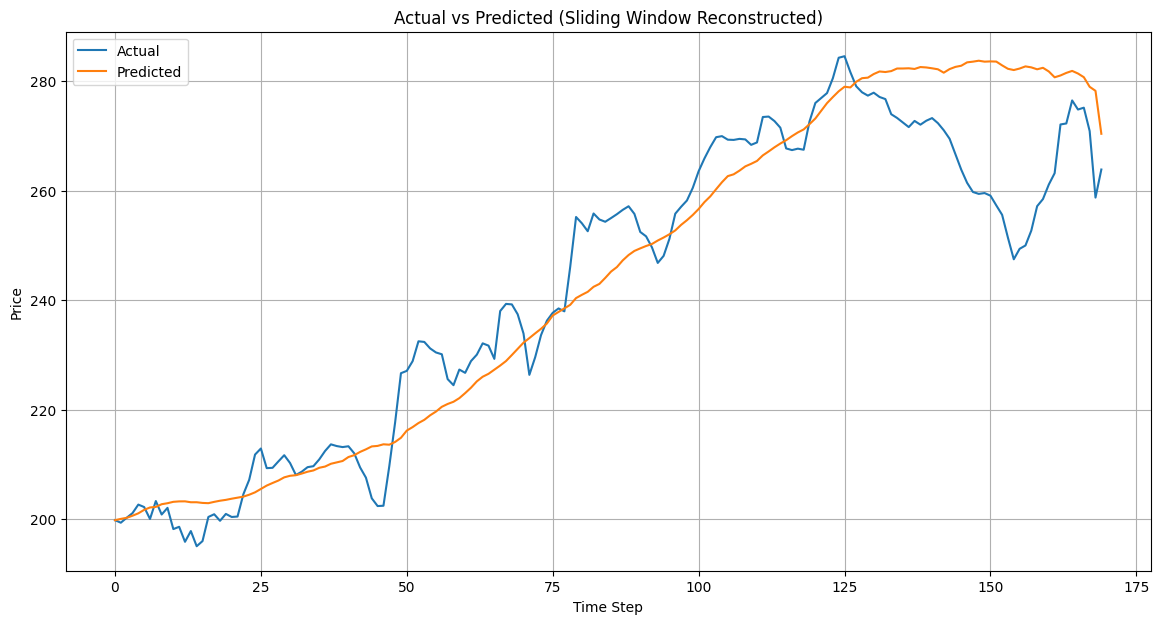

In [18]:
import json
import matplotlib.pyplot as plt
import numpy as np

file_path = "/home/nckh2/qa/SLM/results/gemma/AAPL_lb1_fh28_predictions.json"

with open(file_path, "r") as f:
    data = json.load(f)

horizon = len(data[0]["actual"])

# Determine total timeline length
total_length = len(data) + horizon - 1

# Containers
actual_series = np.zeros(total_length)
actual_count = np.zeros(total_length)

pred_series = np.zeros(total_length)
pred_count = np.zeros(total_length)

# Reconstruct timeline
for i, entry in enumerate(data):
    actual = entry["actual"]
    predicted = entry["predicted"]
    
    for j in range(horizon):
        idx = i + j
        
        actual_series[idx] += actual[j]
        actual_count[idx] += 1
        
        pred_series[idx] += predicted[j]
        pred_count[idx] += 1

# Average overlapping values
actual_series = actual_series / np.where(actual_count == 0, 1, actual_count)
pred_series = pred_series / np.where(pred_count == 0, 1, pred_count)

# Plot
plt.figure(figsize=(14, 7))
plt.plot(actual_series, label="Actual")
plt.plot(pred_series, label="Predicted")

plt.title("Actual vs Predicted (Sliding Window Reconstructed)")
plt.xlabel("Time Step")
plt.ylabel("Price")
plt.legend()
plt.grid(True)

plt.show()

Extracted 143 points for 28-day ahead forecast
MAE:  12.5914
RMSE: 16.1852
MAPE: 4.98%
Saved: /home/nckh2/qa/SLM/results/gemma/plots/AAPL_lb1_28d_forecast.png


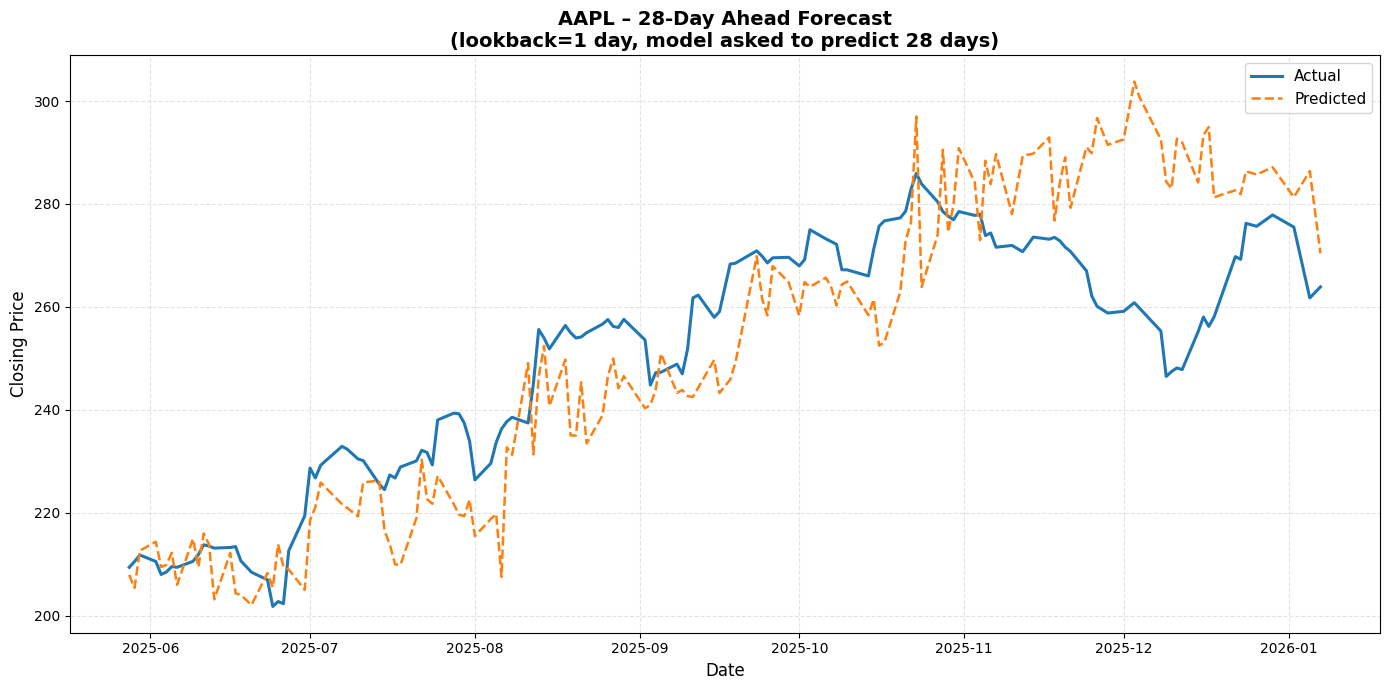

In [7]:
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

# ────────────────────────────────────────────────
#  CONFIG
# ────────────────────────────────────────────────

FILE_PATH = Path("/home/nckh2/qa/SLM/results/gemma/AAPL_lb1_fh28_predictions.json")

# Which horizon do you want to visualize?
HORIZON_DAYS = 28          # ← change this to 1,7,14,21,28 as needed
SAVE_FIG = True
OUTPUT_DIR = FILE_PATH.parent / "plots"
OUTPUT_DIR.mkdir(exist_ok=True)

# ────────────────────────────────────────────────
#  LOAD & EXTRACT
# ────────────────────────────────────────────────

with open(FILE_PATH, "r", encoding="utf-8") as f:
    data = json.load(f)

step_idx = HORIZON_DAYS - 1  # 0-based index

rows = []

for entry in data:
    actual_list = entry.get("actual", [])
    pred_list   = entry.get("predicted", [])
    date_str    = entry.get("date", "unknown")

    if len(actual_list) > step_idx and len(pred_list) > step_idx:
        rows.append({
            "date": date_str,
            "actual": actual_list[step_idx],
            "predicted": pred_list[step_idx]
        })

if not rows:
    print("No valid entries found with enough forecast steps.")
    exit()

df = pd.DataFrame(rows)
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

print(f"Extracted {len(df)} points for {HORIZON_DAYS}-day ahead forecast")

# ────────────────────────────────────────────────
#  BASIC ERROR METRICS
# ────────────────────────────────────────────────

errors = df["actual"] - df["predicted"]
mae  = errors.abs().mean()
rmse = np.sqrt((errors**2).mean())
mape = (errors.abs() / df["actual"]).mean() * 100

print(f"MAE:  {mae:,.4f}")
print(f"RMSE: {rmse:,.4f}")
print(f"MAPE: {mape:.2f}%")

# ────────────────────────────────────────────────
#  PLOT
# ────────────────────────────────────────────────

plt.figure(figsize=(14, 7))

plt.plot(df["date"], df["actual"],    label="Actual",    color="#1f77b4", linewidth=2.2)
plt.plot(df["date"], df["predicted"], label="Predicted", color="#ff7f0e", linewidth=1.8, linestyle="--")

plt.title(f"AAPL – {HORIZON_DAYS}-Day Ahead Forecast\n(lookback=1 day, model asked to predict 28 days)", 
          fontsize=14, fontweight="bold")
plt.xlabel("Date", fontsize=12)
plt.ylabel("Closing Price", fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.35, linestyle="--")

# Optional: add markers every 20 points to see individual forecasts
# plt.scatter(df["date"][::20], df["actual"][::20],    color="#1f77b4", s=40, alpha=0.6, zorder=5)
# plt.scatter(df["date"][::20], df["predicted"][::20], color="#ff7f0e", s=40, alpha=0.6, zorder=5)

plt.tight_layout()

if SAVE_FIG:
    save_name = f"AAPL_lb1_{HORIZON_DAYS}d_forecast.png"
    plt.savefig(OUTPUT_DIR / save_name, dpi=140, bbox_inches="tight")
    print(f"Saved: {OUTPUT_DIR / save_name}")

plt.show()


=== 28-Day Ahead Forecast Metrics ===
MAE  : 12.5914
RMSE : 16.1852
MAPE : 4.98%


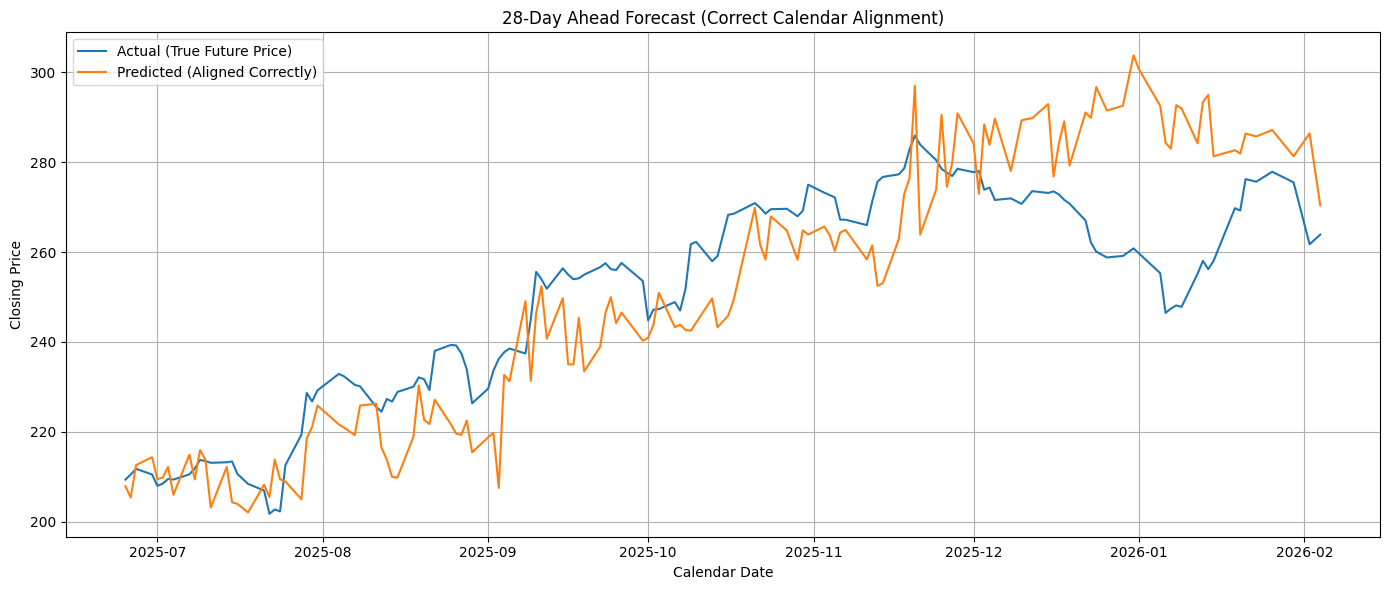

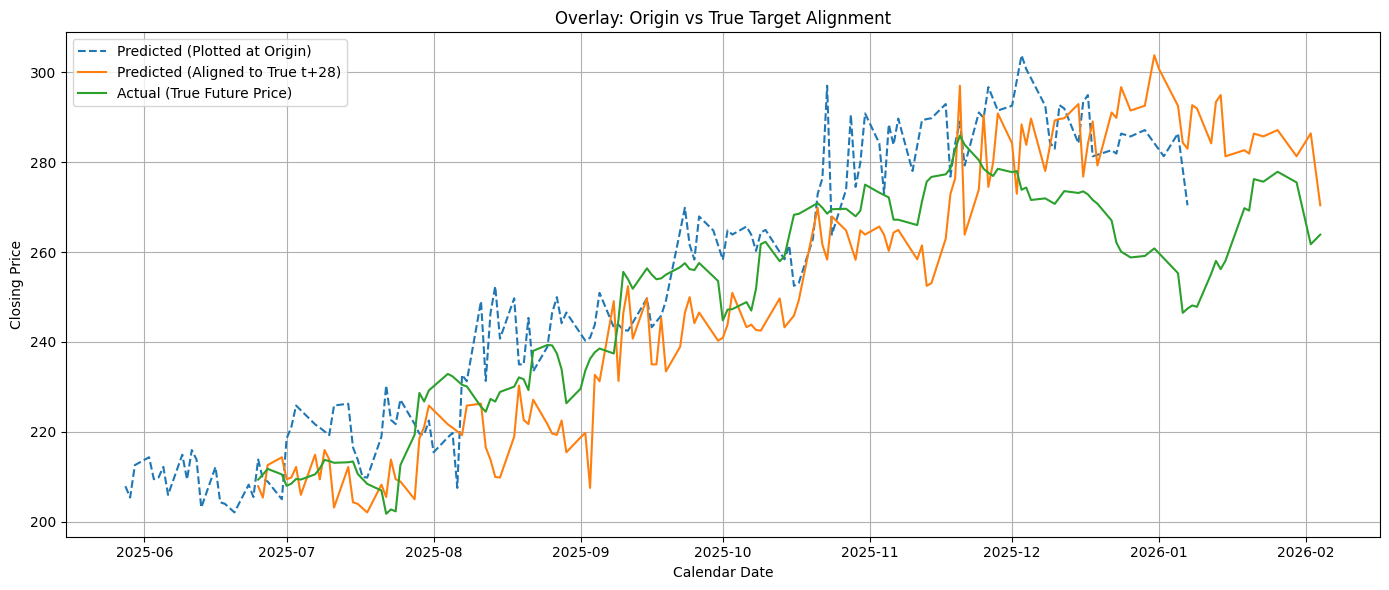

In [9]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ==========================
# CONFIG
# ==========================
HORIZON_DAYS = 28
TARGET_INDEX = HORIZON_DAYS - 1  # 27 for 28-day ahead

JSON_FILE = "/home/nckh2/qa/SLM/results/gemma/AAPL_lb1_fh28_predictions.json"  # change this


# ==========================
# LOAD DATA
# ==========================
with open(JSON_FILE, "r") as f:
    data = json.load(f)


records = []

for row in data:
    origin_date = pd.to_datetime(row["date"])

    # Get 28-day ahead values
    actual_future = row["actual"][TARGET_INDEX]
    predicted_future = row["predicted"][TARGET_INDEX]

    # True calendar target date
    target_date = origin_date + pd.Timedelta(days=HORIZON_DAYS)

    records.append({
        "origin_date": origin_date,
        "target_date": target_date,
        "actual": actual_future,
        "predicted": predicted_future
    })


df = pd.DataFrame(records).sort_values("origin_date").reset_index(drop=True)


# ==========================
# METRICS (CORRECT MATCHING)
# ==========================
mae = mean_absolute_error(df["actual"], df["predicted"])
rmse = np.sqrt(mean_squared_error(df["actual"], df["predicted"]))
mape = np.mean(np.abs((df["actual"] - df["predicted"]) / df["actual"])) * 100

print("\n=== 28-Day Ahead Forecast Metrics ===")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAPE : {mape:.2f}%")


# ==========================
# PLOT 1 — CORRECT ALIGNMENT
# ==========================
plt.figure(figsize=(14,6))

plt.plot(df["target_date"], df["actual"], label="Actual (True Future Price)")
plt.plot(df["target_date"], df["predicted"], label="Predicted (Aligned Correctly)")

plt.title("28-Day Ahead Forecast (Correct Calendar Alignment)")
plt.xlabel("Calendar Date")
plt.ylabel("Closing Price")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ==========================
# PLOT 2 — OVERLAY (Origin vs True)
# ==========================
plt.figure(figsize=(14,6))

# Forecast plotted at origin (shifted left)
plt.plot(df["origin_date"], df["predicted"], "--", label="Predicted (Plotted at Origin)")

# Forecast aligned to true target date
plt.plot(df["target_date"], df["predicted"], label="Predicted (Aligned to True t+28)")

# Actual future price
plt.plot(df["target_date"], df["actual"], label="Actual (True Future Price)")

plt.title("Overlay: Origin vs True Target Alignment")
plt.xlabel("Calendar Date")
plt.ylabel("Closing Price")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Extracted 143 points for 28-day ahead forecast
MAE:  12.5914
RMSE: 16.1852
MAPE: 4.98%
Saved: /home/nckh2/qa/SLM/results/gemma/plots/AAPL_lb1_28d_forecast.png


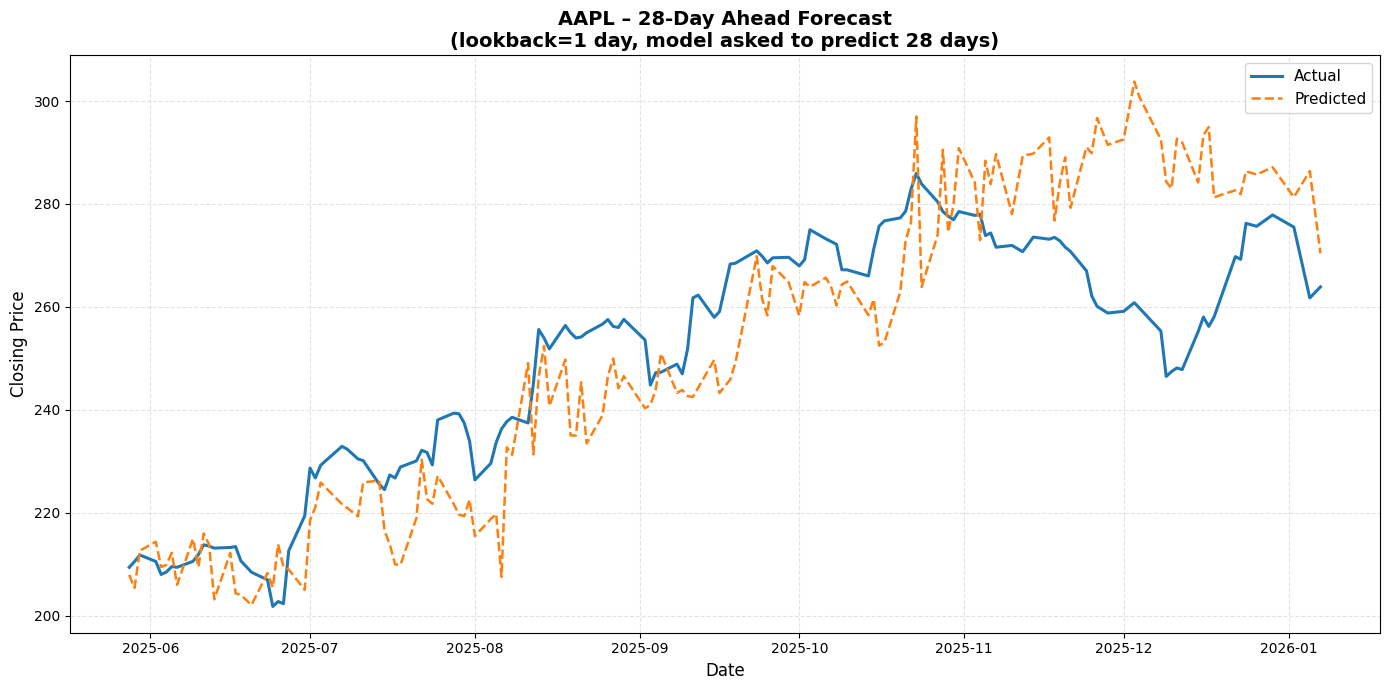

In [ ]:
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

# ────────────────────────────────────────────────
#  CONFIG
# ────────────────────────────────────────────────

FILE_PATH = Path("/home/nckh2/qa/SLM/results/gemma/AAPL_lb1_fh28_predictions.json")

# Which horizon do you want to visualize?
HORIZON_DAYS = 28          # ← change this to 1,7,14,21,28 as needed
SAVE_FIG = True
OUTPUT_DIR = FILE_PATH.parent / "plots"
OUTPUT_DIR.mkdir(exist_ok=True)

# ────────────────────────────────────────────────
#  LOAD & EXTRACT
# ────────────────────────────────────────────────

with open(FILE_PATH, "r", encoding="utf-8") as f:
    data = json.load(f)

step_idx = HORIZON_DAYS - 1  # 0-based index

rows = []

for entry in data:
    actual_list = entry.get("actual", [])
    pred_list   = entry.get("predicted", [])
    date_str    = entry.get("date", "unknown")

    if len(actual_list) > step_idx and len(pred_list) > step_idx:
        rows.append({
            "date": date_str,
            "actual": actual_list[step_idx],
            "predicted": pred_list[step_idx]
        })

if not rows:
    print("No valid entries found with enough forecast steps.")
    exit()

df = pd.DataFrame(rows)
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

print(f"Extracted {len(df)} points for {HORIZON_DAYS}-day ahead forecast")

# ────────────────────────────────────────────────
#  BASIC ERROR METRICS
# ────────────────────────────────────────────────

errors = df["actual"] - df["predicted"]
mae  = errors.abs().mean()
rmse = np.sqrt((errors**2).mean())
mape = (errors.abs() / df["actual"]).mean() * 100

print(f"MAE:  {mae:,.4f}")
print(f"RMSE: {rmse:,.4f}")
print(f"MAPE: {mape:.2f}%")

# ────────────────────────────────────────────────
#  PLOT
# ────────────────────────────────────────────────

plt.figure(figsize=(14, 7))

plt.plot(df["date"], df["actual"],    label="Actual",    color="#1f77b4", linewidth=2.2)
plt.plot(df["date"], df["predicted"], label="Predicted", color="#ff7f0e", linewidth=1.8, linestyle="--")

plt.title(f"AAPL – {HORIZON_DAYS}-Day Ahead Forecast\n(lookback=1 day, model asked to predict 28 days)", 
          fontsize=14, fontweight="bold")
plt.xlabel("Date", fontsize=12)
plt.ylabel("Closing Price", fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.35, linestyle="--")

# Optional: add markers every 20 points to see individual forecasts
# plt.scatter(df["date"][::20], df["actual"][::20],    color="#1f77b4", s=40, alpha=0.6, zorder=5)
# plt.scatter(df["date"][::20], df["predicted"][::20], color="#ff7f0e", s=40, alpha=0.6, zorder=5)

plt.tight_layout()

if SAVE_FIG:
    save_name = f"AAPL_lb1_{HORIZON_DAYS}d_forecast.png"
    plt.savefig(OUTPUT_DIR / save_name, dpi=140, bbox_inches="tight")
    print(f"Saved: {OUTPUT_DIR / save_name}")

plt.show()

In [2]:
import os
import json
import pandas as pd

# ========================= CONFIG =========================
# Paths
GEMMA_DIR = "/home/nckh2/qa/SLM/results/gemma/result"
TRADITIONAL_CSV = "/home/nckh2/qa/SLM/results/traditional/traditional_metrics.csv"
TRANSFORMER_CSV = "/home/nckh2/qa/SLM/results/transformers/stock_transformer_per_stock_metrics.csv"

OUTPUT_CSV = "/home/nckh2/qa/SLM/results/combined_28d_summary.csv"

STOCKS = [
    'AAPL', 'ABBV', 'AMD', 'AMGN', 'AMZN', 'AVGO', 'AXP', 'BAC', 'BLK', 'BMY',
    'C', 'DHR', 'GOOGL', 'GS', 'INTC', 'JNJ', 'JPM', 'LLY', 'META', 'MRK',
    'MS', 'MSFT', 'NVDA', 'ORCL', 'PFE', 'SCHW', 'SPGI', 'TMO', 'UNH', 'WFC'
]

# =========================================================

all_data = []

# ====================== 1. Gemma Results ======================
print("Loading Gemma results...")
for stock in STOCKS:
    json_file = os.path.join(GEMMA_DIR, f"{stock}_lb1_fh28_metrics.json")
    
    if not os.path.exists(json_file):
        continue
    
    try:
        with open(json_file, 'r') as f:
            content = json.load(f)
        
        metrics_list = content.get("metrics_per_step", [])
        metric_28 = next((m for m in metrics_list if m.get("horizon_step") == 28), None)
        
        if metric_28:
            all_data.append({
                'Stock': stock,
                'Model': 'Gemma',
                'MAE': round(metric_28.get('mae'), 4),
                'RMSE': round(metric_28.get('rmse'), 4),
                'MAPE': round(metric_28.get('mape'), 4)
            })
    except:
        pass

# ====================== 2. Traditional Models ======================
print("Loading Traditional models...")
if os.path.exists(TRADITIONAL_CSV):
    trad_df = pd.read_csv(TRADITIONAL_CSV)
    trad_28 = trad_df[['symbol', 'model', 'mae_h28', 'rmse_h28', 'mape_h28']].copy()
    trad_28 = trad_28.rename(columns={
        'symbol': 'Stock',
        'model': 'Model',
        'mae_h28': 'MAE',
        'rmse_h28': 'RMSE',
        'mape_h28': 'MAPE'
    })
    trad_28['MAE'] = trad_28['MAE'].round(4)
    trad_28['RMSE'] = trad_28['RMSE'].round(4)
    trad_28['MAPE'] = trad_28['MAPE'].round(4)
    
    all_data.extend(trad_28.to_dict('records'))

# ====================== 3. Transformer Models ======================
print("Loading Transformer models...")
if os.path.exists(TRANSFORMER_CSV):
    trans_df = pd.read_csv(TRANSFORMER_CSV)
    trans_28 = trans_df[['symbol', 'model', 'mae_h28', 'rmse_h28', 'mape_h28']].copy()
    trans_28 = trans_28.rename(columns={
        'symbol': 'Stock',
        'model': 'Model',
        'mae_h28': 'MAE',
        'rmse_h28': 'RMSE',
        'mape_h28': 'MAPE'
    })
    trans_28['MAE'] = trans_28['MAE'].round(4)
    trans_28['RMSE'] = trans_28['RMSE'].round(4)
    trans_28['MAPE'] = trans_28['MAPE'].round(4)
    
    all_data.extend(trans_28.to_dict('records'))

# ====================== Create Final DataFrame ======================
final_df = pd.DataFrame(all_data)

# Sort by Stock then Model
final_df = final_df.sort_values(by=['Stock', 'Model']).reset_index(drop=True)

# Print the combined table
print("\n" + "="*90)
print("COMBINED MAE & RMSE RESULTS FOR 28-DAY HORIZON")
print("="*90)
print(final_df.to_string(index=False))

# Calculate Mean MAPE
mean_mape = round(final_df['MAPE'].mean(), 4)
print("\n" + "="*90)
print(f"OVERALL Mean MAPE (28-day) across ALL models and stocks:  {mean_mape}")
print("="*90)

# Mean MAPE per Model
print("\n=== Mean MAPE by Model (28-day horizon) ===")
model_mean = final_df.groupby('Model')['MAPE'].mean().round(4).reset_index()
model_mean = model_mean.rename(columns={'MAPE': 'Mean_MAPE'}).sort_values('Mean_MAPE')
print(model_mean.to_string(index=False))

# Save to CSV
os.makedirs(os.path.dirname(OUTPUT_CSV), exist_ok=True)
final_df.to_csv(OUTPUT_CSV, index=False)

print(f"\n✅ Combined summary saved to: {OUTPUT_CSV}")

Loading Gemma results...
Loading Traditional models...
Loading Transformer models...

COMBINED MAE & RMSE RESULTS FOR 28-DAY HORIZON
Stock        Model      MAE     RMSE     MAPE
 AAPL   Autoformer  25.9937  29.0879  10.3600
 AAPL         CLAM  49.2831  52.2091  19.2200
 AAPL     CNN-LSTM  50.7355  52.8996  19.8700
 AAPL    FEDformer  20.0341  26.0767   8.2600
 AAPL          GRU  42.1800  44.0259  16.5700
 AAPL        Gemma  12.5914  16.1852   4.9763
 AAPL     Informer  99.5207 106.0922  38.6600
 AAPL         LSTM  41.7195  43.7440  16.3700
 AAPL iTransformer  17.0411  20.5518   6.7400
 ABBV   Autoformer  12.9761  15.7006   6.0100
 ABBV         CLAM  72.0876  73.1952  33.2100
 ABBV     CNN-LSTM  63.2300  64.1163  29.1400
 ABBV    FEDformer  12.8482  14.8953   5.9800
 ABBV          GRU  23.6048  25.0111  10.8600
 ABBV        Gemma  11.0507  13.1448   5.0915
 ABBV     Informer  66.5108  67.5079  30.6400
 ABBV         LSTM  47.8914  48.7657  22.0600
 ABBV iTransformer  11.6820  13.4985   

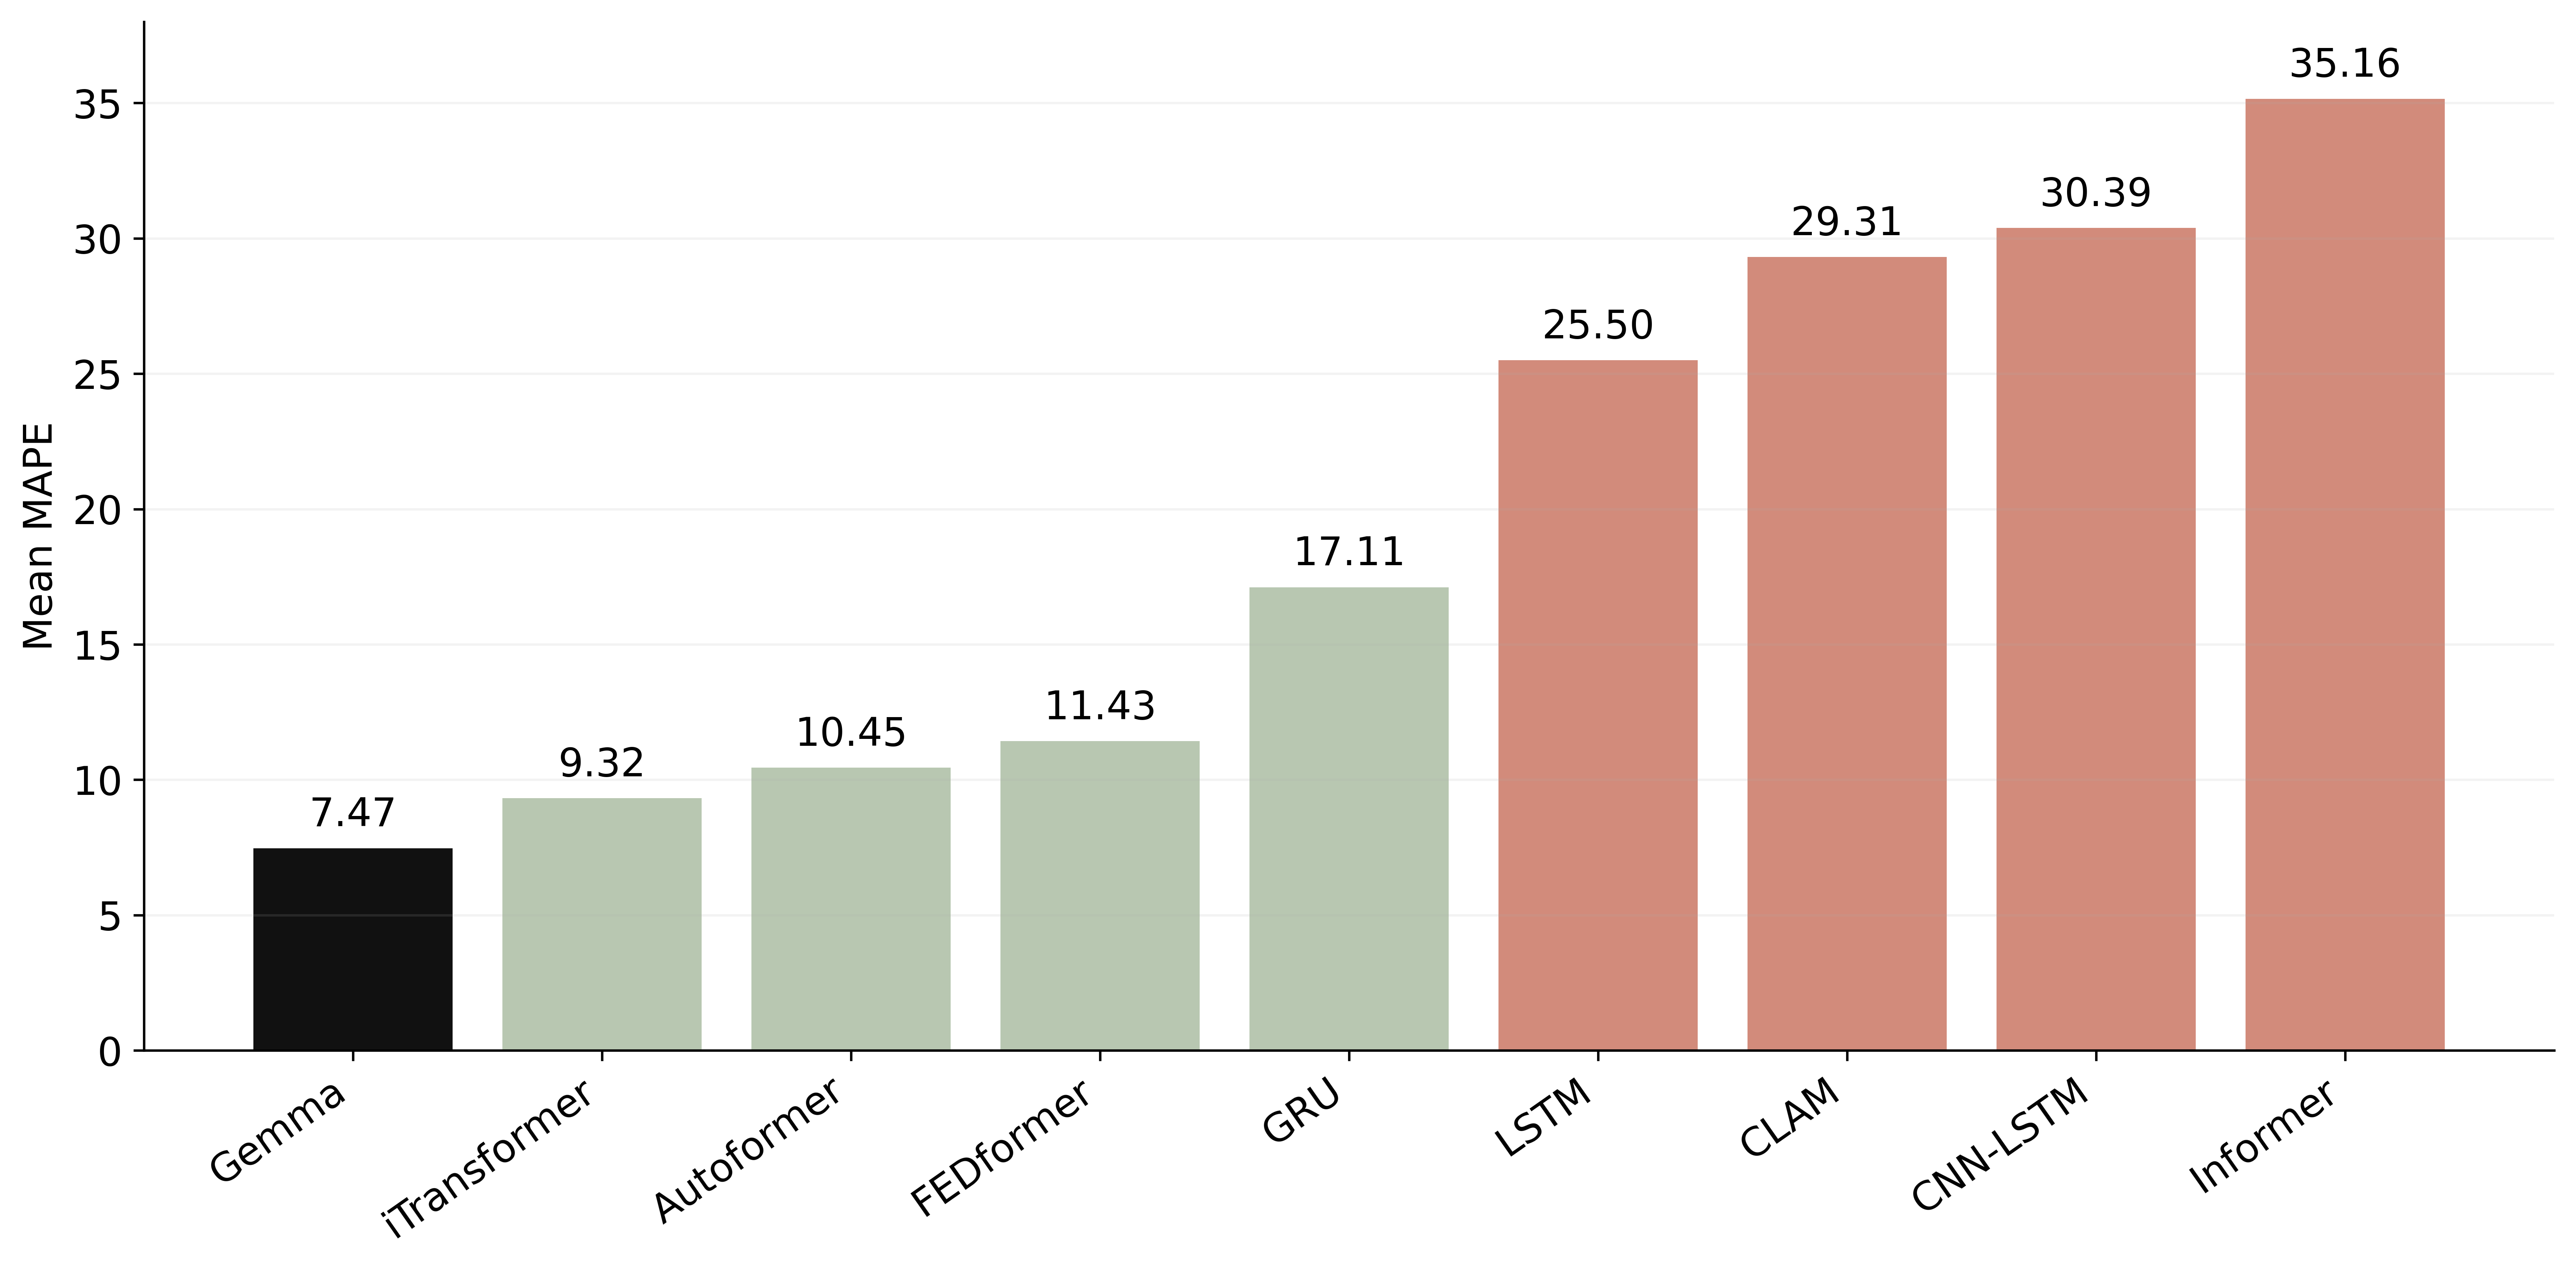

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Global Style
# -----------------------------
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 13,
    "axes.titlesize": 18,
    "axes.labelsize": 13,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
})

# Colors
salmon = "#D28B7B"
black = "#111111"
light_green = "#B8C7B1"

# -----------------------------
# Data
# -----------------------------
models = [
    "Gemma", "iTransformer", "Autoformer",
    "FEDformer", "GRU", "LSTM",
    "CLAM", "CNN-LSTM", "Informer"
]

mape = [
    7.471, 9.321, 10.448,
    11.427, 17.111, 25.499,
    29.307, 30.386, 35.158
]
# -----------------------------
# Figure
# -----------------------------
fig, ax = plt.subplots(figsize=(12, 6), dpi=600)

x = np.arange(len(models))

# Color logic
colors = []
for i, val in enumerate(mape):
    if i == 0:
        colors.append(black)      # Best
    elif val > 20:
        colors.append(salmon)     # Outlier
    else:
        colors.append(light_green)

# Bars
ax.bar(x, mape, color=colors, edgecolor="none")

# Labels
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=35, ha="right")
ax.set_ylabel("Mean MAPE")

# Limits
ax.set_ylim(0, 38)

# Style
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', linestyle='-', alpha=0.15)

# Value annotations
for i, v in enumerate(mape):
    ax.text(i, v + 0.5, f"{v:.2f}", ha='center', va='bottom', fontsize=13)

plt.tight_layout()
plt.show()

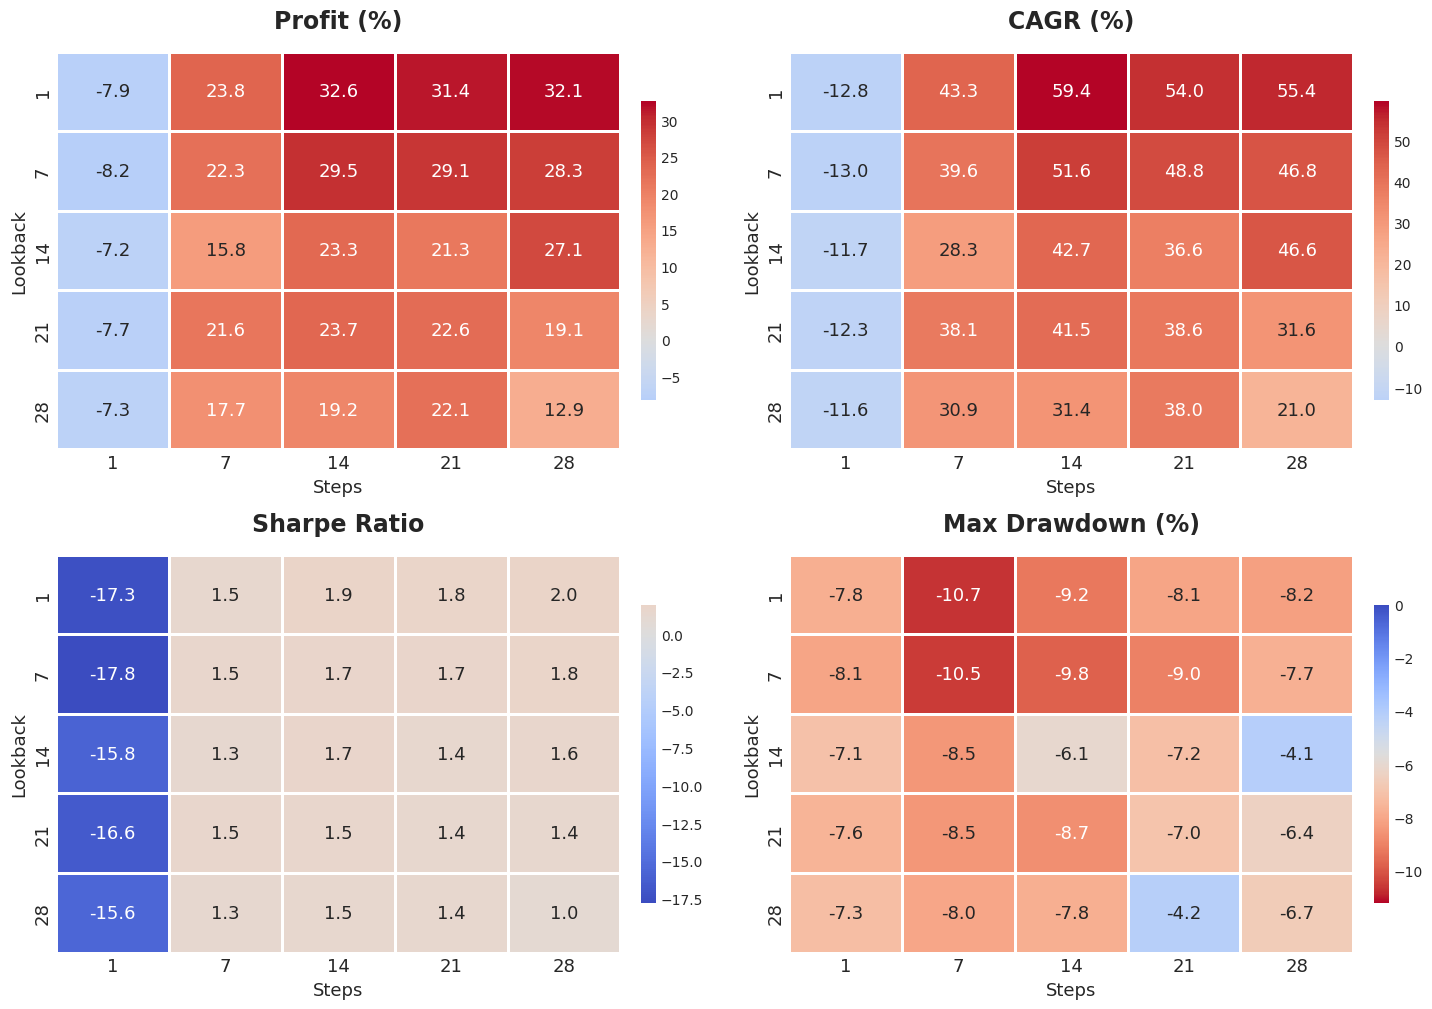

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set clean sans-serif font globally
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans', 'Liberation Sans']

# Load data
file_path = "/home/nckh2/qa/SLM/results/gemma/insights/ultimate/global_best_by_profit.csv"
df = pd.read_csv(file_path)

# Metrics to plot
metrics = {
    "profit_pct_mean": "Profit (%)",
    "cagr_pct_mean": "CAGR (%)",
    "sharpe_mean": "Sharpe Ratio",
    "max_dd_mean": "Max Drawdown (%)"
}

# Create figure
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
axes = axes.flatten()

for ax, (col, title) in zip(axes, metrics.items()):
    pivot = df.pivot(index="lookback", columns="step_days", values=col)
    pivot = pivot.sort_index().sort_index(axis=1)
    
    # Choose colormap
    if col == "max_dd_mean":
        cmap = "coolwarm_r"
        center = None
        vmin = pivot.min().min() * 1.05
        vmax = 0
    else:
        cmap = "coolwarm"
        center = 0
        vmin = None
        vmax = None
    
    sns.heatmap(
        pivot,
        ax=ax,
        annot=True,
        fmt=".1f",
        cmap=cmap,
        center=center,
        vmin=vmin,
        vmax=vmax,
        linewidths=0.8,
        linecolor='white',
        cbar_kws={"shrink": 0.75, "pad": 0.03},
        annot_kws={"size": 13}
    )
    
    # Clean titles and labels - **bold title**
    ax.set_title(title, fontsize=17, pad=17, fontweight='bold')
    ax.set_xlabel("Steps", fontsize=13)
    ax.set_ylabel("Lookback", fontsize=13)
    
    # Tick labels
    ax.tick_params(axis='both', which='major', labelsize=13)

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.93])

# Save high-resolution figure
plt.savefig("combined_heatmaps_clean.png", dpi=700, bbox_inches='tight')

plt.show()

In [11]:
import json
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import pandas as pd
from pathlib import Path

# ========================= CONFIG =========================
RESULTS_DIR = Path("/home/nckh2/qa/SLM/results/gemma/result")
PLOTS_DIR   = RESULTS_DIR / "plots"
PLOTS_DIR.mkdir(exist_ok=True)

mpl.rcParams.update({
    "font.size": 24,
    "axes.titlesize": 24,
    "axes.labelsize": 24,
    "xtick.labelsize": 24,
    "ytick.labelsize": 24,
    "legend.fontsize": 24
})

HORIZON_DAYS = 28
SAVE_FIG = True

# =========================================================

# Find all *_lb1_fh28_predictions.json files
pred_files = sorted(RESULTS_DIR.glob("*_lb1_fh28_predictions.json"))

print(f"Found {len(pred_files)} stocks with lb1_fh28 predictions.\n")

for pred_file in pred_files:
    symbol = pred_file.stem.split("_lb1")[0]   # Extract ticker (e.g., AAPL, NVDA, etc.)
    
    print(f"Processing {symbol} ...")

    try:
        with open(pred_file, "r", encoding="utf-8") as f:
            data = json.load(f)
    except Exception as e:
        print(f"   Error loading {pred_file.name}: {e}")
        continue

    step_idx = HORIZON_DAYS - 1

    rows = []
    for entry in data:
        actual_list = entry.get("actual", [])
        pred_list   = entry.get("predicted", [])
        date_str    = entry.get("date")

        if len(actual_list) > step_idx and len(pred_list) > step_idx:
            rows.append({
                "date": date_str,
                "actual": actual_list[step_idx],
                "predicted": pred_list[step_idx]
            })

    if not rows:
        print(f"   No valid data for {symbol}")
        continue

    df = pd.DataFrame(rows)
    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values("date").reset_index(drop=True)

    # Error metrics
    errors = df["actual"] - df["predicted"]
    mae  = errors.abs().mean()
    rmse = np.sqrt((errors**2).mean())
    mape = (errors.abs() / df["actual"]).mean() * 100

    print(f"   MAE:  {mae:,.4f} | RMSE: {rmse:,.4f} | MAPE: {mape:.2f}%")

    # ========================= PLOT =========================
    plt.figure(figsize=(16, 10))

    plt.plot(df["date"], df["actual"],    label="Actual",    
             color="#1f77b4", linewidth=2.5)
    plt.plot(df["date"], df["predicted"], label=f"Predicted", 
             color="#ff7f0e", linewidth=2.0, linestyle="--")

    plt.title(f"{symbol}",
            #   f"Lookback = 1 day | Model: gemma3:4b", 
              fontsize=26, fontweight="bold", pad=20)

    plt.xlabel("Date", fontsize=26)
    plt.ylabel("Closing Price (USD)", fontsize=24)
    plt.legend(fontsize=26)
    plt.grid(True, alpha=0.3)

    # Optional: show individual forecast points
    plt.scatter(df["date"], df["actual"],    color="#1f77b4", s=15, alpha=0.7)
    plt.scatter(df["date"], df["predicted"], color="#ff7f0e", s=15, alpha=0.7)

    plt.tight_layout()

    if SAVE_FIG:
        save_name = f"{symbol}"
        save_path = PLOTS_DIR / save_name
        plt.savefig(save_path, dpi=400, bbox_inches="tight")
        print(f"   Saved: {save_name}")

    plt.close()   # Close figure to free memory

    print(f"   Done with {symbol}\n")

print("All plots generated successfully!")

Found 30 stocks with lb1_fh28 predictions.

Processing AAPL ...
   MAE:  12.5914 | RMSE: 16.1852 | MAPE: 4.98%
   Saved: AAPL
   Done with AAPL

Processing ABBV ...
   MAE:  11.0507 | RMSE: 13.1448 | MAPE: 5.09%
   Saved: ABBV
   Done with ABBV

Processing AMD ...
   MAE:  36.5604 | RMSE: 43.3870 | MAPE: 17.89%
   Saved: AMD
   Done with AMD

Processing AMGN ...
   MAE:  17.9112 | RMSE: 21.9169 | MAPE: 5.78%
   Saved: AMGN
   Done with AMGN

Processing AMZN ...
   MAE:  13.8501 | RMSE: 18.3710 | MAPE: 6.20%
   Saved: AMZN
   Done with AMZN

Processing AVGO ...
   MAE:  26.6377 | RMSE: 34.4367 | MAPE: 8.01%
   Saved: AVGO
   Done with AVGO

Processing AXP ...
   MAE:  17.1920 | RMSE: 22.7374 | MAPE: 5.07%
   Saved: AXP
   Done with AXP

Processing BAC ...
   MAE:  2.3124 | RMSE: 3.0806 | MAPE: 4.54%
   Saved: BAC
   Done with BAC

Processing BLK ...
   MAE:  62.4661 | RMSE: 82.8881 | MAPE: 5.80%
   Saved: BLK
   Done with BLK

Processing BMY ...
   MAE:  3.5916 | RMSE: 4.4215 | MAPE: 7.

In [ ]:
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

# ========================= CONFIG =========================
RESULTS_DIR = Path("/home/nckh2/qa/SLM/results/gemma/result")
PLOTS_DIR   = RESULTS_DIR / "plots_all_lookbacks"
PLOTS_DIR.mkdir(exist_ok=True)

HORIZON_DAYS = 28
SAVE_FIG = True

LOOKBACKS = [1, 7, 14, 21, 28]

# Colors for different lookbacks
COLORS = {
    1:  "#1f77b4",   # blue
    7:  "#ff7f0e",   # orange
    14: "#2ca02c",   # green
    21: "#d62728",   # red
    28: "#9467bd"    # purple
}

# =========================================================

# Find all unique symbols (from lb1 files)
pred_files = list(RESULTS_DIR.glob("*_lb1_fh28_predictions.json"))
symbols = sorted([f.stem.split("_lb1")[0] for f in pred_files])

print(f"Found {len(symbols)} stocks. Generating multi-lookback plots...\n")

for symbol in symbols:
    print(f"Processing {symbol} ...")

    plt.figure(figsize=(16, 9))

    actual_plotted = False
    metrics_summary = {}

    for lb in LOOKBACKS:
        pred_file = RESULTS_DIR / f"{symbol}_lb{lb}_fh28_predictions.json"
        
        if not pred_file.exists():
            print(f"   Warning: Missing {pred_file.name}")
            continue

        try:
            with open(pred_file, "r", encoding="utf-8") as f:
                data = json.load(f)
        except Exception as e:
            print(f"   Error loading {pred_file.name}: {e}")
            continue

        step_idx = HORIZON_DAYS - 1
        rows = []

        for entry in data:
            actual_list = entry.get("actual", [])
            pred_list   = entry.get("predicted", [])
            date_str    = entry.get("date")

            if len(actual_list) > step_idx and len(pred_list) > step_idx:
                rows.append({
                    "date": date_str,
                    "actual": actual_list[step_idx],
                    "predicted": pred_list[step_idx]
                })

        if not rows:
            continue

        df = pd.DataFrame(rows)
        df["date"] = pd.to_datetime(df["date"])
        df = df.sort_values("date").reset_index(drop=True)

        # Plot Predicted line
        label = f"Lookback {lb} days"
        plt.plot(df["date"], df["predicted"], 
                 label=label, 
                 color=COLORS[lb], 
                 linewidth=2.0, 
                 linestyle='--' if lb != 1 else '-')

        # Plot Actual only once
        if not actual_plotted:
            plt.plot(df["date"], df["actual"], 
                     label="Actual", 
                     color="black", 
                     linewidth=2.8, 
                     alpha=0.85)
            actual_plotted = True

        # Calculate metrics
        errors = df["actual"] - df["predicted"]
        mae  = errors.abs().mean()
        rmse = np.sqrt((errors**2).mean())
        mape = (errors.abs() / df["actual"].replace(0, np.nan)).mean() * 100

        metrics_summary[lb] = {"MAE": mae, "RMSE": rmse, "MAPE": mape}

        print(f"   lb{lb:2d} → MAE: {mae:6.4f} | RMSE: {rmse:6.4f} | MAPE: {mape:5.2f}%")

    if not actual_plotted:
        print(f"   No data available for {symbol}")
        plt.close()
        continue

    # ========================= PLOT SETTINGS =========================
    plt.title(f"{symbol} — 28-Day Ahead Forecast Comparison\n"
              f"Different Lookback Periods (Model: gemma3:4b)", 
              fontsize=26, fontweight="bold", pad=25)

    plt.xlabel("Date", fontsize=26)
    plt.ylabel("Closing Price (USD)", fontsize=26)
    plt.legend(fontsize=26, loc="best")
    plt.grid(True, alpha=0.35)

    # Add metrics as text box
    textstr = "\n".join([f"LB{lb:2d}: MAE={m['MAE']:.3f}  MAPE={m['MAPE']:.1f}%" 
                        for lb, m in metrics_summary.items()])
    
    plt.text(0.02, 0.95, textstr, transform=plt.gca().transAxes, fontsize=26,
             verticalalignment='top', bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8))

    plt.tight_layout()

    if SAVE_FIG:
        save_name = f"{symbol}_28d_all_lookbacks_comparison.png"
        save_path = PLOTS_DIR / save_name
        plt.savefig(save_path, dpi=160, bbox_inches="tight")
        print(f"   Saved: {save_name}")

    plt.close()
    print(f"   Completed {symbol}\n")

print("="*80)
print(f"All multi-lookback plots saved in: {PLOTS_DIR}")
print("Done!")

Found 30 stocks. Generating multi-lookback plots...

Processing AAPL ...
   lb 1 → MAE: 12.5914 | RMSE: 16.1852 | MAPE:  4.98%
   lb 7 → MAE: 16.4192 | RMSE: 24.0223 | MAPE:  6.56%
   lb14 → MAE: 15.9983 | RMSE: 20.7911 | MAPE:  6.40%
   lb21 → MAE: 15.3647 | RMSE: 20.5199 | MAPE:  6.15%
   lb28 → MAE: 15.5249 | RMSE: 18.9790 | MAPE:  6.21%
   Saved: AAPL_28d_all_lookbacks_comparison.png
   Completed AAPL

Processing ABBV ...
   lb 1 → MAE: 11.0507 | RMSE: 13.1448 | MAPE:  5.09%
   lb 7 → MAE: 14.5024 | RMSE: 24.8111 | MAPE:  6.69%
   lb14 → MAE: 11.2366 | RMSE: 13.7615 | MAPE:  5.22%
   lb21 → MAE: 13.1565 | RMSE: 22.0744 | MAPE:  6.09%
   lb28 → MAE: 12.6506 | RMSE: 17.5859 | MAPE:  5.85%
   Saved: ABBV_28d_all_lookbacks_comparison.png
   Completed ABBV

Processing AMD ...
   lb 1 → MAE: 36.5604 | RMSE: 43.3870 | MAPE: 17.89%
   lb 7 → MAE: 43.2734 | RMSE: 54.8300 | MAPE: 20.89%
   lb14 → MAE: 35.6381 | RMSE: 45.4856 | MAPE: 17.31%
   lb21 → MAE: 36.6477 | RMSE: 45.0385 | MAPE: 18.02


Processing AMD... Done
Processing AAPL... Done
Processing GS... Done
Processing C... Done
Processing UNH... Done
Processing MRK... Done
Processing SCHW... Done
Processing JPM... Done
Processing AVGO... Done
Processing BAC... Done
Processing JNJ... Done
Processing AMZN... Done
Processing DHR... Done
Processing NVDA... Done
Processing BLK... Done
Processing BMY... Done
Processing INTC... Done
Processing PFE... Done
Processing SPGI... Done
Processing GOOGL... Done
Processing AMGN... Done
Processing TMO... Done
Processing WFC... Done
Processing AXP... Done
Processing MSFT... Done
Processing MS... Done
Processing ORCL... Done
Processing ABBV... Done
Processing META... Done
Processing LLY... 

Done

Averaged data across 30 stocks. Creating heatmaps...



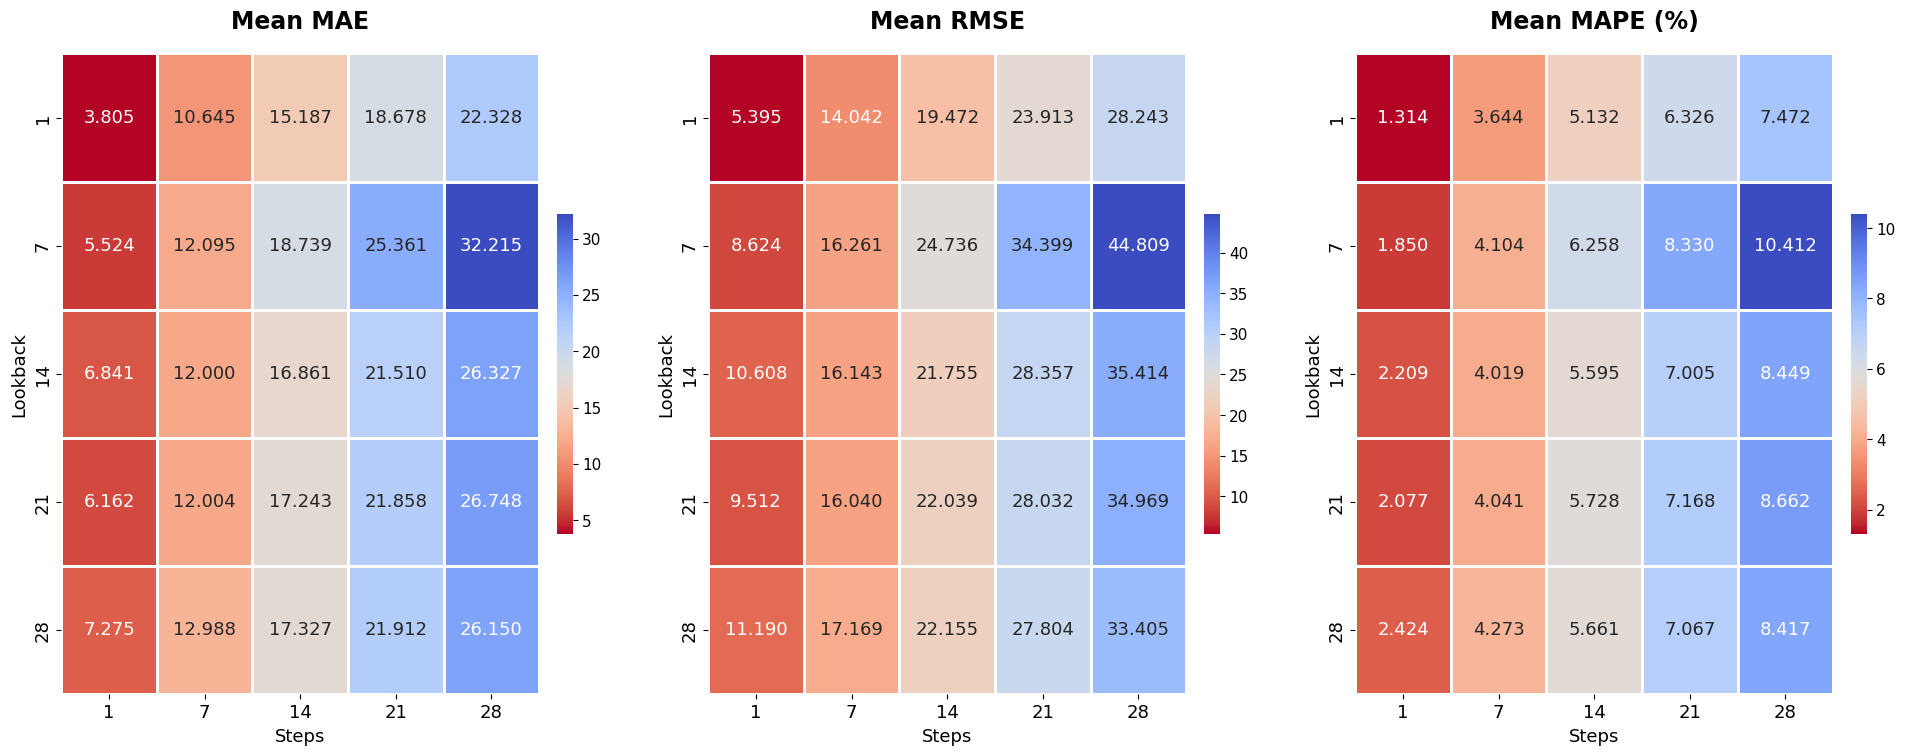


Heatmap successfully saved at:
/home/nckh2/qa/SLM/results/gemma/result/heatmaps_average/ALL_STOCKS_Average_Performance_Heatmap.png

Done!


In [ ]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path

# ========================= CONFIG =========================
RESULTS_DIR = Path("/home/nckh2/qa/SLM/results/gemma/result")
PLOTS_DIR   = RESULTS_DIR / "heatmaps_average"
PLOTS_DIR.mkdir(exist_ok=True)

LOOKBACKS = [1, 7, 14, 21, 28]
EVAL_STEPS = [1, 7, 14, 21, 28]

# Font settings
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = [
    'Arial', 'Helvetica', 'DejaVu Sans', 'Liberation Sans'
]

# Global font sizes
TITLE_SIZE = 17
LABEL_SIZE = 13
TICK_SIZE = 13
ANNOT_SIZE = 13
CBAR_TICK_SIZE = 13   # 👈 colorbar font size

# =========================================================

print("Collecting data from all stocks and computing averages...\n")

metrics_data = []

# Get all unique symbols
pred_files = list(RESULTS_DIR.glob("*_lb1_fh28_predictions.json"))
symbols = [f.stem.split("_lb1")[0] for f in pred_files]

for symbol in symbols:
    print(f"Processing {symbol}...", end=" ")

    for lb in LOOKBACKS:
        pred_file = RESULTS_DIR / f"{symbol}_lb{lb}_fh28_predictions.json"
        if not pred_file.exists():
            continue

        try:
            with open(pred_file, "r", encoding="utf-8") as f:
                data = json.load(f)
        except Exception:
            continue

        for step in EVAL_STEPS:
            step_idx = step - 1
            actuals, preds = [], []

            for entry in data:
                act_list = entry.get("actual", [])
                pred_list = entry.get("predicted", [])

                if len(act_list) > step_idx and len(pred_list) > step_idx:
                    actuals.append(act_list[step_idx])
                    preds.append(pred_list[step_idx])

            if not actuals:
                continue

            actuals = np.array(actuals)
            preds = np.array(preds)
            errors = actuals - preds

            mae = np.mean(np.abs(errors))
            rmse = np.sqrt(np.mean(errors**2))
            mape = (
                np.mean(np.abs(errors / actuals)) * 100
                if np.all(actuals != 0) else np.nan
            )

            metrics_data.append({
                "lookback": lb,
                "step_days": step,
                "MAE": mae,
                "RMSE": rmse,
                "MAPE": mape
            })

    print("Done")

# ========================= DATAFRAME =========================
df = pd.DataFrame(metrics_data)

avg_df = (
    df.groupby(["lookback", "step_days"])[["MAE", "RMSE", "MAPE"]]
    .mean()
    .reset_index()
)

print(f"\nAveraged data across {len(symbols)} stocks. Creating heatmaps...\n")

# ========================= PLOTTING =========================
fig, axes = plt.subplots(1, 3, figsize=(20, 8.5))

metrics_config = {
    "MAE":  ("Mean MAE", "coolwarm_r"),
    "RMSE": ("Mean RMSE", "coolwarm_r"),
    "MAPE": ("Mean MAPE (%)", "coolwarm_r")
}

for ax, (col, (title, cmap)) in zip(axes, metrics_config.items()):

    pivot = (
        avg_df.pivot(index="lookback", columns="step_days", values=col)
        .sort_index()
        .sort_index(axis=1)
    )

    # Create heatmap
    hm = sns.heatmap(
        pivot,
        ax=ax,
        annot=True,
        fmt=".3f",
        cmap=cmap,
        linewidths=1.0,
        linecolor='white',
        cbar_kws={"shrink": 0.75, "pad": 0.03},
        annot_kws={"size": ANNOT_SIZE}
    )

    # 👇 Colorbar font size control
    cbar = hm.collections[0].colorbar
    cbar.ax.tick_params(labelsize=CBAR_TICK_SIZE)

    # Titles & labels
    ax.set_title(title, fontsize=TITLE_SIZE, fontweight='bold', pad=18)
    ax.set_xlabel("Steps", fontsize=LABEL_SIZE)
    ax.set_ylabel("Lookback", fontsize=LABEL_SIZE)

    # Tick size
    ax.tick_params(axis='both', which='major', labelsize=TICK_SIZE)

# Layout
plt.tight_layout(rect=[0, 0, 1, 0.95])

# ========================= SAVE =========================
save_path = PLOTS_DIR / "ALL_STOCKS_Average_Performance_Heatmap.png"

plt.savefig(save_path, dpi=600, bbox_inches='tight')
plt.show()

print("\nHeatmap successfully saved at:")
print(save_path)
print("\nDone!")

In [ ]:
import os
import pandas as pd

# Base directory
base_path = "/home/nckh2/qa/SLM/results/gemma/insights/backtest"

# List of stock symbols
symbols = [
    "AAPL","ABBV","AMD","AMGN","AMZN","AVGO","AXP","BAC","BLK","BMY",
    "C","DHR","GOOGL","GS","INTC","JNJ","JPM","LLY","META","MRK",
    "MS","MSFT","NVDA","ORCL","PFE","SCHW","SPGI","TMO","UNH","WFC"
]

# Store results
results = []

for symbol in symbols:
    folder_path = os.path.join(base_path, symbol)
    
    # Find CSV files in the folder
    for file in os.listdir(folder_path):
        if file.endswith(".csv"):
            file_path = os.path.join(folder_path, file)
            
            try:
                df = pd.read_csv(file_path)
                
                # Filter required conditions
                filtered = df[
                    (df["lookback"] == 1) &
                    (df["step_days"] == 28)
                ]
                
                if not filtered.empty:
                    row = filtered.iloc[0]
                    
                    results.append({
                        "symbol": symbol,
                        "profit_pct": row["profit_pct"],
                        "cagr_pct": row["cagr_pct"],
                        "sharpe": row["sharpe"],
                        "max_dd_pct": row["max_dd_pct"]
                    })
                    
            except Exception as e:
                print(f"Error reading {file_path}: {e}")

# Create final DataFrame
result_df = pd.DataFrame(results)

# Sort (optional)
result_df = result_df.sort_values(by="sharpe", ascending=False)

# Display
print(result_df)

# Save to CSV (optional)
output_path = os.path.join(base_path, "summary_lookback1_step28.csv")
result_df.to_csv(output_path, index=False)

print(f"\nSaved to: {output_path}")